# EDA Forecasting - Tesis (QuickBooks)

Exploracion de calidad, cobertura temporal, distribuciones y variabilidad para pronostico de produccion.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dataset.py').exists():
    ROOT = ROOT.parent
if not (ROOT / 'src' / 'dataset.py').exists():
    raise RuntimeError('No se encontro src/dataset.py. Abre el notebook dentro de 03_modelado/tesis_forecasting.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.dataset import load_monthly_production_dataset


In [2]:
df = load_monthly_production_dataset(source='dwh', fallback_quickbooks=True)
print('rows=', len(df), 'productos=', df['producto'].nunique(), 'periodos=', df['periodo'].nunique())
display(df.head())

rows= 12381 productos= 1002 periodos= 21


F:\proyecto-integrador\Avance 2\03_modelado\tesis_forecasting\src\postgres_loader.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,producto,anio,mes,qty_fabricada,qty_planificada,n_ordenes,periodo
0,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024,7,6960.0,8110.0,5,2024-07-01
1,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024,8,5440.0,7840.0,2,2024-08-01
2,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024,9,6426.0,6811.0,7,2024-09-01
3,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024,10,8439.0,10080.0,11,2024-10-01
4,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024,11,7770.0,8720.0,8,2024-11-01


In [3]:
quality = pd.DataFrame({
    'rows': [len(df)],
    'productos': [df['producto'].nunique()],
    'periodos': [df['periodo'].nunique()],
    'duplicados_producto_periodo': [int(df.duplicated(['producto','periodo']).sum())],
    'null_qty_fabricada': [int(df['qty_fabricada'].isna().sum())],
    'null_qty_planificada': [int(df['qty_planificada'].isna().sum())]
})
display(quality)

,rows,productos,periodos,duplicados_producto_periodo,null_qty_fabricada,null_qty_planificada
0,12381,1002,21,0,0,0


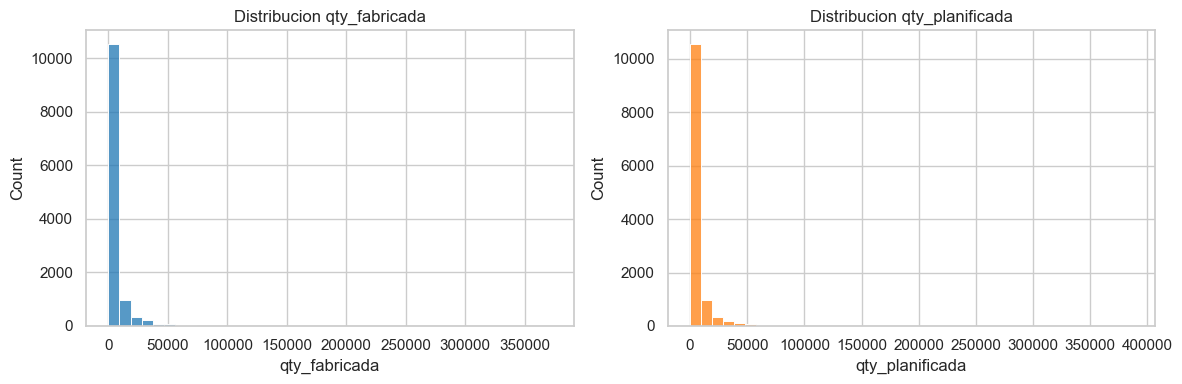

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['qty_fabricada'], bins=40, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion qty_fabricada')
sns.histplot(df['qty_planificada'], bins=40, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Distribucion qty_planificada')
plt.tight_layout()
plt.show()

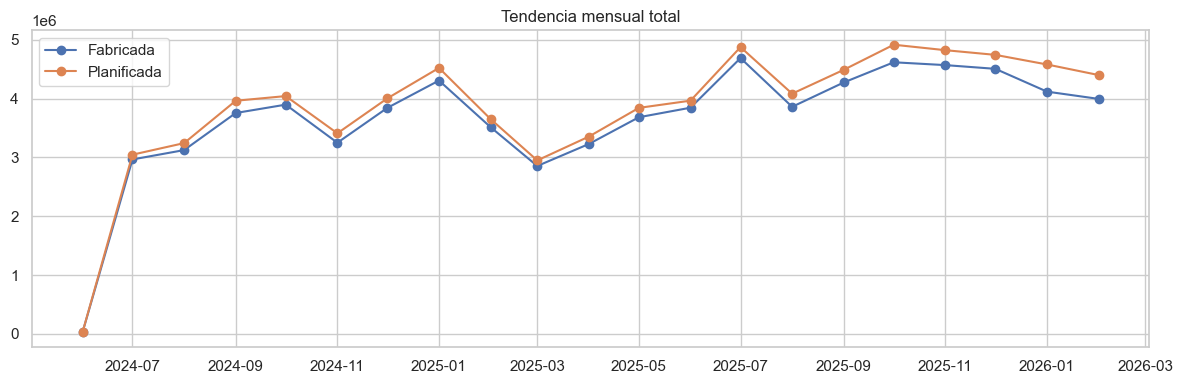

In [5]:
monthly = df.groupby('periodo', as_index=False)[['qty_fabricada','qty_planificada']].sum().sort_values('periodo')
plt.figure(figsize=(12,4))
plt.plot(monthly['periodo'], monthly['qty_fabricada'], marker='o', label='Fabricada')
plt.plot(monthly['periodo'], monthly['qty_planificada'], marker='o', label='Planificada')
plt.title('Tendencia mensual total')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
stats = df.groupby('producto', as_index=False).agg(media=('qty_fabricada','mean'), std=('qty_fabricada','std'), periodos=('periodo','nunique'))
stats['std'] = stats['std'].fillna(0)
stats['cv'] = stats['std'] / stats['media'].replace(0, pd.NA)
display(stats.sort_values('media', ascending=False).head(15))
display(stats.sort_values('cv', ascending=False).head(15))

,producto,media,std,periodos,cv
455,ALINO COMPLETO KILOS GRANEL,192897.416667,121425.764036,12,0.629484
498,ENG ACHIOTE PASTA DP X 30(0.10),181389.750000,46478.028326,20,0.256233
470,CEBOLLA PAITEÑA PELADA,112135.916667,74575.198167,12,0.665043
503,ENG ALIÑO DP X 30 (0.10),95667.631579,39624.156856,19,0.414186
420,ACEITE PALMA _SOYA 70/30 LITROS,93584.750000,42222.206387,8,0.451165
517,ENG CANELA RAMA DISP X 15 (0.20,90031.538462,23513.253655,13,0.261167
513,ENG BICARBONATO X 30 (0.15),84078.500000,19870.519892,20,0.236333
703,MAQUILA SUPERMAXI > EL ARTESANAL ACEITE VEGETA...,82871.777778,29195.393137,9,0.352296
518,ENG CANELA RAMA DISP X 30 (0.15,78237.500000,29593.239455,8,0.378249
971,SAZON COMPLETA KILOS GRANEL,63430.366667,10009.103304,15,0.157797


,producto,media,std,periodos,cv
786,MAQUILA SUPERMAXI > LA ORIGINAL ACEIT GIRASOL ...,12012.000000,20805.394301,3,1.732051
869,MAQUILA SUPERMAXI > SUPERMAXI > SUPER ALIÑO CO...,18410.000000,29988.641831,10,1.628932
26,1 CONDIMENSA > COMBOS > COMBO N.5 SAZON380G+ A...,380.333333,543.885572,12,1.430023
892,MAYONESA BAJA EN CALORIAS KILOS,195.205000,276.061558,2,1.414214
480,COMBO ALINO BOTELLA 310G,975.000000,1378.858223,2,1.414214
584,MAQUILA > DON YAKA PIMIENTA PICAN MOL 30G,512.666667,645.725432,3,1.259542
577,MAQUILA > DON YAKA COMINO MOLIDO 30G(0452,420.000000,521.965516,4,1.242775
692,MAQUILA SUPERMAXI > EL ARTESANAL > EL ARTES. H...,3192.500000,3642.211058,10,1.140865
30,1 CONDIMENSA > COMBOS > COMBO N.9 ACHIOTE + GI...,756.666667,859.903095,3,1.136436
148,1 CONDIMENSA > CONDIMENTOS EN POLVO > PAPRIKA ...,6.888889,7.166667,9,1.040323
